In [1]:
import numpy as np
import pandas as pd
import random
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
import sys
import math
import shap

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
NUTS0 = 'GR'
Q = 'Q3'
q = 'q3'

In [3]:
file1 = f'../data/CMacedonia/{NUTS0}_CMacedonia_WNV_Dataset_{Q}_2011_2022.csv'
file2 = f'../data/Attica/{NUTS0}_Attica_WNV_Dataset_{Q}_2011_2022.csv'
file3 = f'../data/Thessaly/{NUTS0}_Thessaly_WNV_Dataset_{Q}_2011_2022.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)

In [4]:
dataset1.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,16.140356,25.591355,21.290235,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.454731,-0.183245,0.246524,-0.246524,0.444107,-0.170003,0.250130,-0.250130,0.054694,0.037628,0.055227,0.055227,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.25,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,17.421654,27.999990,21.668700,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.378583,-0.233879,0.132150,-0.132150,0.373756,-0.230329,0.130451,-0.130451,0.059430,0.054023,0.059993,0.059993,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.51,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,17.769485,28.501489,19.865039,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.356537,-0.260447,0.098562,-0.098562,0.356282,-0.257762,0.100835,-0.100835,0.047118,0.033747,0.050085,0.050085,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.52,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,16.496359,26.274069,20.873664,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.442904,-0.203153,0.219985,-0.219985,0.440181,-0.201061,0.219940,-0.219940,0.050468,0.039873,0.053010,0.053010,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.34,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,16.849642,26.986681,22.586039,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.418954,-0.198718,0.206012,-0.206012,0.415985,-0.185722,0.213826,-0.213826,0.059560,0.043850,0.062738,0.062738,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.03,5025.2,5265.4,18910.088889,0


In [5]:
dataset2.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,8.777903,20.170519,31.078387,32.642185,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,0.247551,-0.182368,0.079455,-0.079455,0.249847,-0.186561,0.077217,-0.077217,0.033705,0.022287,0.023810,0.023810,293537.0,45883.0,200375.0,47279.0,324283.0,43595.0,220412.0,60276.0,18689.14,2605.2,3841.2,17366.277778,1
1,2011,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,9.456237,21.932668,33.195161,32.595574,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,0.174031,-0.178666,0.025206,-0.025206,0.167300,-0.180944,0.017834,-0.017834,0.025586,0.016485,0.014229,0.014229,252508.0,38921.0,179791.0,33796.0,259441.0,36714.0,177899.0,44828.0,7131.89,2605.2,3841.2,22230.111111,1
2,2011,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,9.503973,21.248946,32.160102,31.582155,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,0.204773,-0.149678,0.062690,-0.062690,0.199747,-0.147951,0.059373,-0.059373,0.040707,0.028420,0.026886,0.026886,521694.0,64868.0,377784.0,79042.0,569144.0,61544.0,388717.0,118883.0,39021.83,2605.2,3841.2,19777.421053,1
3,2011,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,9.247935,21.118014,31.921968,31.206384,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,0.194478,-0.186140,0.030849,-0.030849,0.188257,-0.182074,0.029487,-0.029487,0.026456,0.021707,0.021393,0.021393,263293.0,38993.0,183267.0,41033.0,291408.0,36789.0,199070.0,55549.0,12606.74,2605.2,3841.2,21091.900000,1
4,2011,EL30,αττικη,EL305,ανατολικη αττικη,23.889386,38.042726,8.145652,19.117302,30.001501,33.211956,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,0.366031,-0.272629,0.094886,-0.094886,0.362359,-0.267013,0.096231,-0.096231,0.033897,0.028630,0.032696,0.032696,259185.0,43417.0,180372.0,35396.0,252043.0,41239.0,171976.0,38828.0,13091.44,2605.2,3841.2,15911.479310,1


In [6]:
dataset3.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,3.686851,16.075582,26.194276,26.421316,15.333333,19.166667,46.747967,795.536792,38.0,-3.0,41.0,15.000000,25.500000,25.500000,6.000000,2002.0,348.0,9.0,63.000736,812.0,142.0,142.0,702.0,0.397419,-0.147194,0.224026,-0.224026,0.396718,-0.146377,0.223808,-0.223808,0.056012,0.058159,0.061354,0.061354,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.13,10080.6,10176.8,5230.598616,1
1,2011,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,4.875334,18.121586,29.505567,22.503622,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.362258,-0.193909,0.155312,-0.155312,0.362993,-0.192573,0.158199,-0.158199,0.052767,0.039836,0.057991,0.057991,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.45,6268.6,6460.0,4285.480144,1
2,2011,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,5.750763,17.620242,27.951788,27.447041,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.406250,-0.171623,0.207952,-0.207952,0.401349,-0.167704,0.209458,-0.209458,0.050077,0.049983,0.052770,0.052770,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.99,6268.6,6460.0,2948.510417,1
3,2012,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,1.038181,16.693490,28.248765,32.928373,13.958333,19.250000,49.358974,841.929152,35.0,-4.0,39.0,3.833333,24.333333,24.333333,3.833333,1223.0,212.0,2.0,63.539911,472.0,91.0,91.0,472.0,0.385594,-0.192493,0.174467,-0.174467,0.382494,-0.184611,0.179313,-0.179313,0.059209,0.057437,0.066948,0.066948,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.51,10080.6,10176.8,5014.138408,0
4,2012,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,2.947811,18.932507,30.892895,25.737431,15.916667,22.500000,48.913043,906.249347,42.0,-4.0,46.0,10.166667,27.333333,27.333333,5.666667,928.0,123.0,4.0,50.136650,314.0,136.0,136.0,284.0,0.338948,-0.251534,0.087278,-0.087278,0.337294,-0.255910,0.082401,-0.082401,0.060063,0.043734,0.063525,0.063525,143171.0,23273.0,93519.0,26379.0,147118.0,22079.0,93390.0,31649.0,4125.73,6268.6,6460.0,4641.090253,0


In [7]:
dataset = pd.concat([dataset1, dataset2, dataset3])

In [8]:
dataset

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,16.140356,25.591355,21.290235,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.454731,-0.183245,0.246524,-0.246524,0.444107,-0.170003,0.250130,-0.250130,0.054694,0.037628,0.055227,0.055227,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,17.421654,27.999990,21.668700,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.378583,-0.233879,0.132150,-0.132150,0.373756,-0.230329,0.130451,-0.130451,0.059430,0.054023,0.059993,0.059993,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,17.769485,28.501489,19.865039,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.356537,-0.260447,0.098562,-0.098562,0.356282,-0.257762,0.100835,-0.100835,0.047118,0.033747,0.050085,0.050085,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,16.496359,26.274069,20.873664,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.442904,-0.203153,0.219985,-0.219985,0.440181,-0.201061,0.219940,-0.219940,0.050468,0.039873,0.053010,0.053010,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,16.849642,26.986681,22.586039,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.418954,-0.198718,0.206012,-0.206012,0.415985,-0.185722,0.213826,-0.213826,0.059560,0.043850,0.062738,0.062738,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,18.380755,28.484998,33.850996,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.398211,-0.365509,0.087651,-0.087651,0.388426,-0.356267,0.091034,-0.091034,0.060048,0.045394,0.064120,0.064120,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
162,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,18.380755,28.484998,33.850996,18.250000,22.166667,47.163121,871.388651,44.0,-3.0,47.0,10.000000,25.833333,28.333333,7.333333,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.398211,-0.365509,0.087651,-0.087651,0.388426,-0.356267,0.091034,-0.091034,0.060048,0.045394,0.064120,0.064120,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3078.914,2621.0,2977.0,11643.101083,1
163,2022,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.041349,18.380755,28.4849

In [9]:
dataset.drop_duplicates(keep='first', inplace=True, ignore_index=True)

In [10]:
dataset

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,EL52,κεντρικη μακεδονια,EL521,ημαθια,22.215876,40.552658,3.154111,16.140356,25.591355,21.290235,14.583333,18.666667,49.122807,768.952455,34.0,-4.0,38.0,9.166667,23.833333,23.833333,4.833333,1580.0,347.0,21.0,69.297060,585.0,195.0,195.0,488.0,0.454731,-0.183245,0.246524,-0.246524,0.444107,-0.170003,0.250130,-0.250130,0.054694,0.037628,0.055227,0.055227,70507.0,11806.0,44835.0,13866.0,72328.0,11360.0,44584.0,16384.0,2016.250,5025.2,5265.4,18028.909091,1
1,2011,EL52,κεντρικη μακεδονια,EL522,θεσσαλονικη,23.139532,40.695359,3.805192,17.421654,27.999990,21.668700,16.125000,20.083333,46.705426,865.533204,39.0,-4.0,43.0,10.333333,26.166667,26.500000,5.333333,1341.0,362.0,8.0,88.115950,512.0,157.0,210.0,391.0,0.378583,-0.233879,0.132150,-0.132150,0.373756,-0.230329,0.130451,-0.130451,0.059430,0.054023,0.059993,0.059993,544496.0,87330.0,375115.0,82051.0,593794.0,84172.0,402246.0,107376.0,19627.510,9804.6,10058.8,16320.850394,1
2,2011,EL52,κεντρικη μακεδονια,EL523,κιλκις,22.758634,41.016242,3.615530,17.769485,28.501489,19.865039,16.083333,21.500000,46.739130,890.054476,41.0,-5.0,46.0,9.833333,26.166667,27.000000,5.000000,1417.0,379.0,10.0,78.775725,584.0,198.0,223.0,377.0,0.356537,-0.260447,0.098562,-0.098562,0.356282,-0.257762,0.100835,-0.100835,0.047118,0.033747,0.050085,0.050085,40335.0,5963.0,24603.0,9769.0,41005.0,5680.0,23436.0,11889.0,1124.520,5809.2,5920.4,14407.043956,0
3,2011,EL52,κεντρικη μακεδονια,EL524,πελλα,22.109199,40.888821,3.344699,16.496359,26.274069,20.873664,14.750000,19.166667,47.916667,790.425662,36.0,-4.0,40.0,9.333333,24.500000,24.500000,4.666667,1630.0,348.0,19.0,63.316479,629.0,219.0,219.0,490.0,0.442904,-0.203153,0.219985,-0.219985,0.440181,-0.201061,0.219940,-0.219940,0.050468,0.039873,0.053010,0.053010,70390.0,11159.0,44537.0,14694.0,71954.0,11052.0,43212.0,17690.0,1938.340,5025.2,5265.4,15360.034091,1
4,2011,EL52,κεντρικη μακεδονια,EL525,πιερια,22.441443,40.269748,4.506731,16.849642,26.986681,22.586039,15.916667,18.333333,45.833333,769.247960,37.0,-3.0,40.0,15.666667,25.500000,25.500000,6.500000,1470.0,325.0,27.0,70.741701,556.0,174.0,174.0,437.0,0.418954,-0.198718,0.206012,-0.206012,0.415985,-0.185722,0.213826,-0.213826,0.059560,0.043850,0.062738,0.062738,62665.0,10433.0,40170.0,12062.0,65045.0,10152.0,40273.0,14620.0,1725.030,5025.2,5265.4,18910.088889,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,2021,EL61,θεσσαλια,EL612,λαρισα,22.405497,39.703383,5.210389,18.864162,29.759256,27.827196,17.291667,22.250000,49.444444,888.169295,41.0,-4.0,45.0,15.833333,25.666667,28.333333,7.000000,1006.0,205.0,14.0,63.055735,412.0,156.0,178.0,202.0,0.390514,-0.363326,0.090385,-0.090385,0.382105,-0.356293,0.091042,-0.091042,0.062715,0.046057,0.065152,0.065152,135989.0,21482.0,85156.0,29351.0,144295.0,20120.0,88927.0,35248.0,3864.930,4121.0,5185.0,10578.321300,0
200,2021,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.869212,39.281871,6.336408,18.313418,28.284036,21.844752,16.875000,18.416667,47.222222,833.155284,38.0,-1.0,39.0,15.333333,27.000000,27.000000,7.333333,1052.0,250.0,14.0,73.900286,497.0,122.0,122.0,215.0,0.432682,-0.373784,0.166147,-0.166147,0.426418,-0.371645,0.162577,-0.162577,0.063069,0.048691,0.061782,0.061782,98350.0,13938.0,63669.0,20743.0,104051.0,13179.0,64890.0,25982.0,2354.660,6670.0,7132.0,1813.322917,0
201,2022,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.719540,39.504234,4

In [11]:
dataset.columns

Index(['year', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y',
       'min_temp_q3', 'mean_temp_q3', 'max_temp_q3', 'prec_q3', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q3', 'ndwi_q3', 'ndmi_q3', 'ndbi_q3', 'ndvi_mean_q3',
       'ndwi_mean_q3', 'ndmi_mean_q3', 'ndbi_mean_q3', 'ndvi_std_q3',
       'ndwi_std_q3', 'ndmi_std_q3', 'ndbi_std_q3', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens', 'WNV_cases'],
      dtype='object')

In [12]:
print(f'Number of NUTS3 Units in dataset: {len(dataset.NUTS3_NAME.unique())}')

Number of NUTS3 Units in dataset: 17


In [13]:
dsc = dataframe_describe(dataset, target_column = 'WNV_cases')
dsc.head(15)

,year,non-case,case,total,percentage
0,2011,2,15,17,8.33%
1,2012,8,9,17,8.33%
2,2013,9,8,17,8.33%
3,2014,16,1,17,8.33%
4,2015,17,0,17,8.33%
5,2016,17,0,17,8.33%
6,2017,17,0,17,8.33%
7,2018,2,15,17,8.33%
8,2019,5,12,17,8.33%
9,2020,7,10,17,8.33%


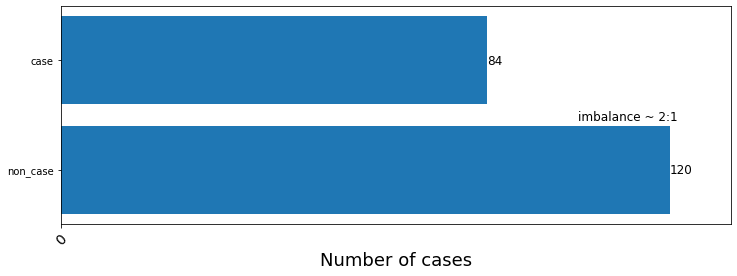

In [14]:
plot_imbalance(dataset, target_column='WNV_cases')

In [15]:
majority_class = 0
near_u = 0
smote = 0.05
scaler = 'minmax'
weight_multiplier = 1

years_to_remove = []
features_to_remove = ['x', 'y', 'year']
#features_to_remove=[]
#years_to_remove = []

In [16]:
model_coefficients = []
model_shaps = []
results_train = pd.DataFrame()
results_test = pd.DataFrame()
feature_names = dataset.select_dtypes(exclude=['object']).drop(columns = ['WNV_cases'] 
                                                               + features_to_remove).columns

print(feature_names)

Index(['min_temp_q3', 'mean_temp_q3', 'max_temp_q3', 'prec_q3', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q3', 'ndwi_q3', 'ndmi_q3', 'ndbi_q3', 'ndvi_mean_q3',
       'ndwi_mean_q3', 'ndmi_mean_q3', 'ndbi_mean_q3', 'ndvi_std_q3',
       'ndwi_std_q3', 'ndmi_std_q3', 'ndbi_std_q3', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens'],
      dtype='object')


In [17]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
x = dataset.drop(columns = ['WNV_cases'])
y = dataset['WNV_cases']
fold = 0
  
for train_idx, test_idx in skf.split(x, y):
    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]
    data_test = data_test.drop_duplicates(keep='first')
    if len(years_to_remove) > 0:
        data_train = data_train.loc[~data_train['year'].isin(years_to_remove)]
    
    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)
    
    X_train, X_test, y_train, y_test, scaler, imputer = train_test_split_transform(data_train, data_test, near_u, smote, 'WNV_cases', scaler, majority_class, features_to_remove)

    w0,w1 = calculate_weights_new(y_train, weight_multiplier)

    model = LogisticRegression(max_iter = 1000, class_weight = {0.0: w0, 1.0:w1}, n_jobs = -1, random_state = 0)

    trained_model, model_shap = train_lin_model(model, X_train, y_train, explain=True)

    train, test, coef = predict_lin_model_new(trained_model, X_train, y_train, X_test, y_test, data_test, day_col = None, month_col = None, spatial_col = 'NUTS3_NAME')

    results_train = results_train.append(train, ignore_index = True)
    results_test = results_test.append(test, ignore_index = True)
    model_coefficients.append(coef)
    model_shaps.append(model_shap)
    
    print(f"Fold: {fold} || w0:{w0}, w1:{w1} || ##")
    fold = fold + 1

shap_values= np.concatenate(model_shaps, axis=0)

Fold: 0 || w0:1, w1:2 || ##
Fold: 1 || w0:1, w1:2 || ##
Fold: 2 || w0:1, w1:2 || ##
Fold: 3 || w0:1, w1:2 || ##
Fold: 4 || w0:1, w1:2 || ##
Fold: 5 || w0:1, w1:2 || ##
Fold: 6 || w0:1, w1:2 || ##
Fold: 7 || w0:1, w1:2 || ##
Fold: 8 || w0:1, w1:2 || ##
Fold: 9 || w0:1, w1:2 || ##


In [18]:
feature_names

Index(['min_temp_q3', 'mean_temp_q3', 'max_temp_q3', 'prec_q3', 'bio1', 'bio2',
       'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10',
       'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18',
       'bio19', 'ndvi_q3', 'ndwi_q3', 'ndmi_q3', 'ndbi_q3', 'ndvi_mean_q3',
       'ndwi_mean_q3', 'ndmi_mean_q3', 'ndbi_mean_q3', 'ndvi_std_q3',
       'ndwi_std_q3', 'ndmi_std_q3', 'ndbi_std_q3', 'M_TOTAL', 'M_Y_LT_15',
       'M_Y15-64', 'M_Y_GE65', 'F_TOTAL', 'F_Y_LT_15', 'F_Y15-64', 'F_Y_GE65',
       'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL', 'culex_pipiens'],
      dtype='object')

In [19]:
len(feature_names)

47

In [20]:
bioclimatic = ['bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']
climate = [f'min_temp_{q}', f'mean_temp_{q}', f'max_temp_{q}', f'prec_{q}']
enviromental = [f'ndvi_{q}',f'ndwi_{q}',f'ndmi_{q}',f'ndbi_{q}',f'ndvi_mean_{q}',f'ndwi_mean_{q}',f'ndmi_mean_{q}',f'ndbi_mean_{q}',f'ndvi_std_{q}',f'ndwi_std_{q}',f'ndmi_std_{q}',f'ndbi_std_{q}']
demographic = ['M_TOTAL','M_Y_LT_15','M_Y15-64','M_Y_GE65','F_TOTAL','F_Y_LT_15','F_Y15-64','F_Y_GE65']
vectors = ['culex_pipiens']
trade = ['L_TOTAL',	'UNL_TOTAL']
economic = ['MIO_EUR']

In [21]:
len(bioclimatic+climate+enviromental+demographic+vectors+trade+economic)

47

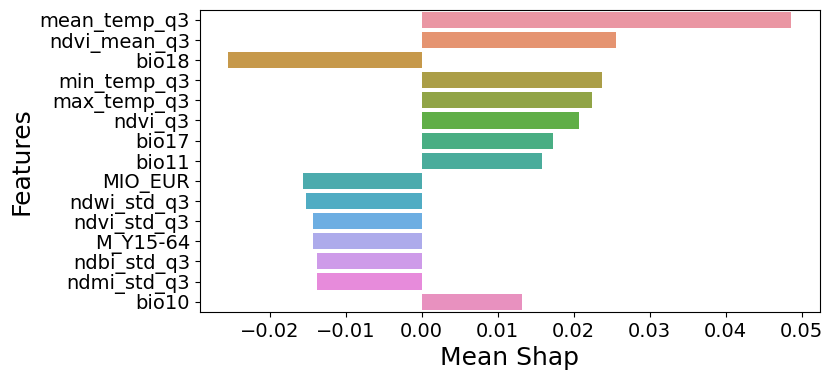

In [22]:
mean_shap = shap_values.mean(axis=0)
shp = mean_shap.shape[0]
mean_shap = mean_shap.reshape(1,shp)

shaps = plot_feature_importance(mean_shap, feature_names, x_label = 'Mean Shap', top = 15, figure_size = (8, 4))

shaps['weights_abs'] = shaps['weights'].apply(lambda x: abs(x))

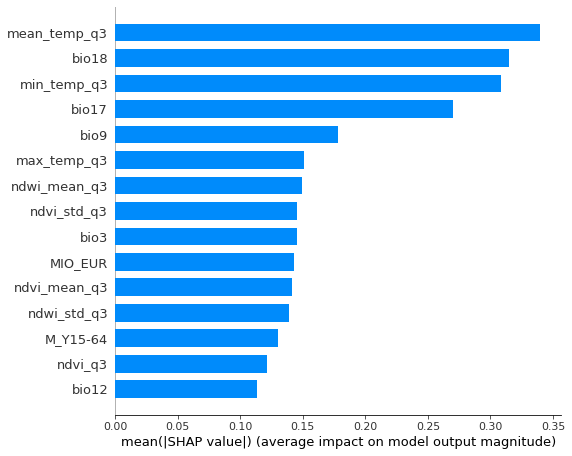

In [23]:
shap.summary_plot(shap_values, features = X_train, feature_names = feature_names, plot_type='bar', max_display=15)

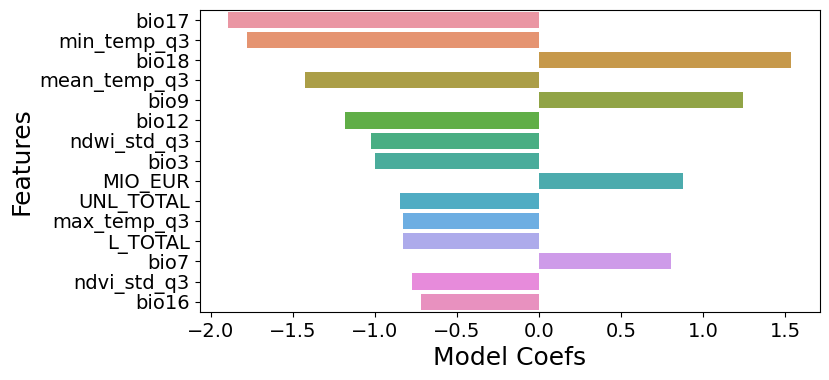

In [24]:
coefs = plot_feature_importance(model_coefficients, feature_names, x_label = 'Model Coefs', top = 15, figure_size = (8, 4))

,features,weights
2,enviromental,0.143930
0,bioclimatic,0.141317
1,climate,0.095004
3,demographic,0.054166
6,economic,0.015615
5,trade,0.006672
4,vectors,0.002487


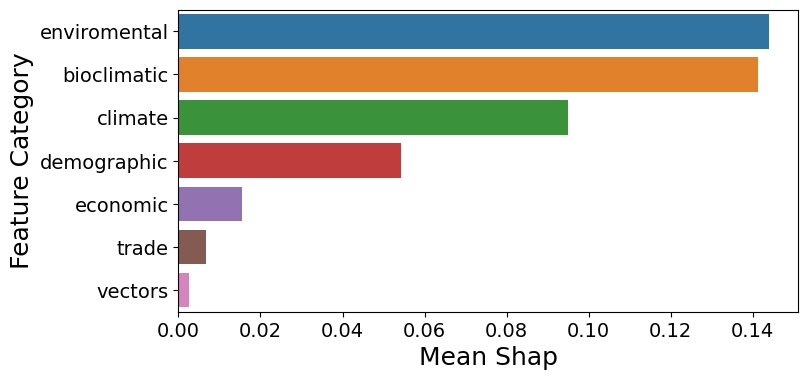

In [25]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.sum(),df_climate.weights_abs.sum(),df_enviromental.weights_abs.sum(),
                            df_demographic.weights_abs.sum(),df_vectors.weights_abs.sum(),df_trade.weights_abs.sum(),df_economic.weights_abs.sum()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

,features,weights
1,climate,0.023751
6,economic,0.015615
2,enviromental,0.011994
0,bioclimatic,0.007438
3,demographic,0.006771
5,trade,0.003336
4,vectors,0.002487


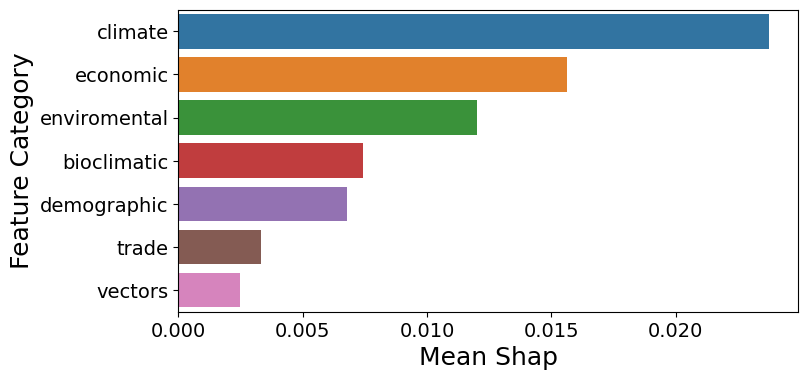

In [26]:
df_bioclimatic = shaps.loc[shaps['features'].isin(bioclimatic)].drop(columns=['weights'])
df_climate = shaps.loc[shaps['features'].isin(climate)].drop(columns=['weights'])
df_enviromental = shaps.loc[shaps['features'].isin(enviromental)].drop(columns=['weights'])
df_demographic = shaps.loc[shaps['features'].isin(demographic)].drop(columns=['weights'])
df_vectors = shaps.loc[shaps['features'].isin(vectors)].drop(columns=['weights'])
df_trade = shaps.loc[shaps['features'].isin(trade)].drop(columns=['weights'])
df_economic = shaps.loc[shaps['features'].isin(economic)].drop(columns=['weights'])

categories = {'Category': ['bioclimatic', 'climate', 'enviromental', 'demographic', 'vectors', 'trade', 'economic'], 
              'Mean_Shap': [df_bioclimatic.weights_abs.mean(),df_climate.weights_abs.mean(),df_enviromental.weights_abs.mean(),
                            df_demographic.weights_abs.mean(),df_vectors.weights_abs.mean(),df_trade.weights_abs.mean(),df_economic.weights_abs.mean()]}

categories_df = pd.DataFrame.from_dict(categories)

categories_df.sort_values(by = 'Mean_Shap', ascending=False)

mean_shap_categories = categories_df['Mean_Shap']
mean_shap_categories = mean_shap_categories.to_numpy().reshape(1,7)

plot_feature_importance(mean_shap_categories, categories_df['Category'], y_label='Feature Category', x_label = 'Mean Shap', figure_size = (8, 4))

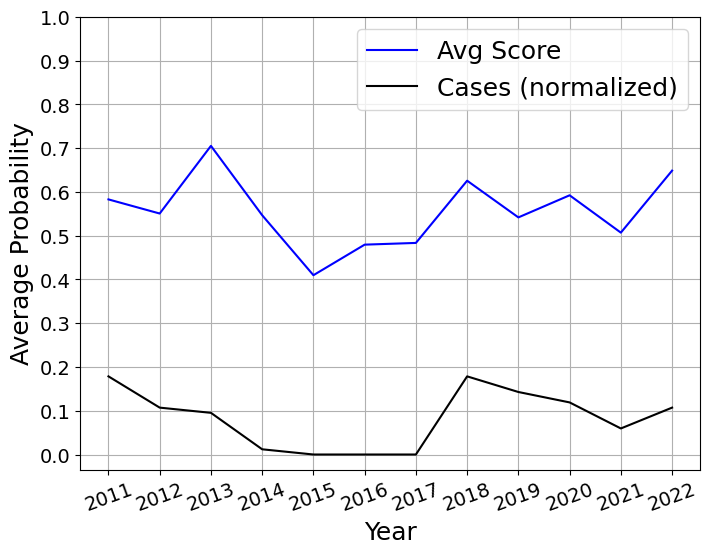

In [27]:
plot_trend_curve(results_test, score_col='score', cases=list(dsc['case']))

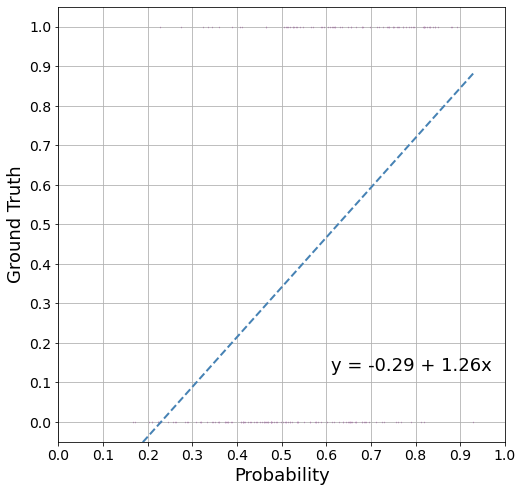

(-0.28913472413787955, 1.2601114868856325)

In [28]:
plot_probability_curve(results_test)

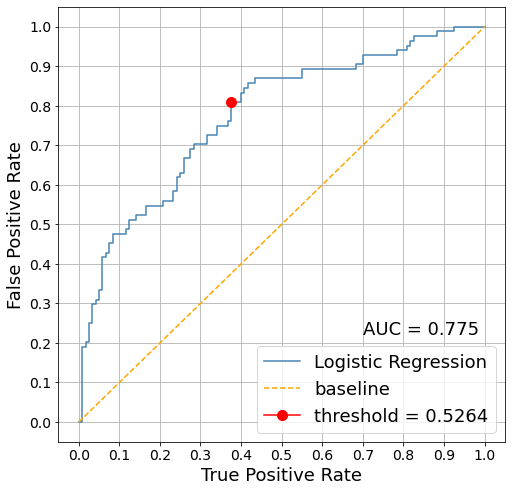

(0.375, 0.8095, 0.5264, 0.7113)

In [29]:
plot_roc_curve(results_test, plot_gmean=True)

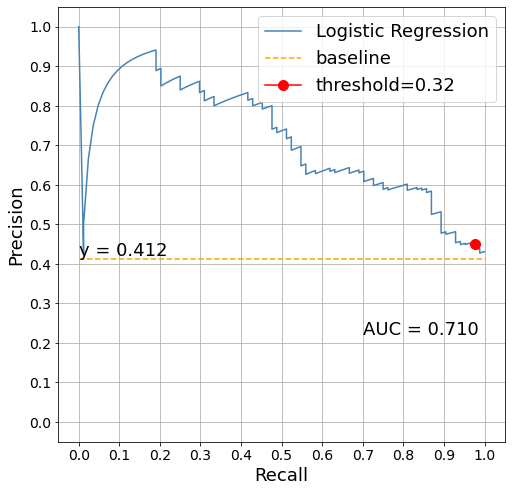

(0.9762, 0.45, 0.32, 0.793)

In [30]:
plot_pr_curve(results_test, plot_fbeta=True)

In [31]:
results_test

,NUTS3_NAME,year,case,score
0,θεσσαλονικη,2014,0,0.928961
1,θεσσαλονικη,2011,1,0.899843
2,ημαθια,2020,1,0.893260
3,πελλα,2022,1,0.880862
4,θεσσαλονικη,2013,1,0.879887
...,...,...,...,...
199,νοτιος τομεας αθηνων,2016,0,0.210661
200,δυτικος τομεας αθηνων,2016,0,0.209088
201,δυτικη αττικη,2017,0,0.203036
202,χαλκιδικη,2016,0,0.171574


In [32]:
results_test['pred_01'] = results_test['score'].apply(lambda x: 1 if x>= 0.1 else 0)
results_test['pred_02'] = results_test['score'].apply(lambda x: 1 if x>= 0.2 else 0)
results_test['pred_05'] = results_test['score'].apply(lambda x: 1 if x>= 0.5 else 0)

In [33]:
results_test

,NUTS3_NAME,year,case,score,pred_01,pred_02,pred_05
0,θεσσαλονικη,2014,0,0.928961,1,1,1
1,θεσσαλονικη,2011,1,0.899843,1,1,1
2,ημαθια,2020,1,0.893260,1,1,1
3,πελλα,2022,1,0.880862,1,1,1
4,θεσσαλονικη,2013,1,0.879887,1,1,1
...,...,...,...,...,...,...,...
199,νοτιος τομεας αθηνων,2016,0,0.210661,1,1,0
200,δυτικος τομεας αθηνων,2016,0,0.209088,1,1,0
201,δυτικη αττικη,2017,0,0.203036,1,1,0
202,χαλκιδικη,2016,0,0.171574,1,0,0


In [34]:
accuracy_01 = accuracy_score(results_test.case, results_test.pred_01)
balanced_accuracy_01 = balanced_accuracy_score(results_test.case, results_test.pred_01)
fb_score_01 = fbeta_score(results_test.case, results_test.pred_01, beta = 1, labels = [0,1], zero_division = 0)
precision_01 = precision_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
recall_01 = recall_score(results_test.case, results_test.pred_01, labels = [0,1], zero_division = 0)
logloss_01 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [35]:
accuracy_02 = accuracy_score(results_test.case, results_test.pred_02)
balanced_accuracy_02 = balanced_accuracy_score(results_test.case, results_test.pred_02)
fb_score_02 = fbeta_score(results_test.case, results_test.pred_02, beta = 1, labels = [0,1], zero_division = 0)
precision_02 = precision_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
recall_02 = recall_score(results_test.case, results_test.pred_02, labels = [0,1], zero_division = 0)
logloss_02 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [36]:
accuracy_05 = accuracy_score(results_test.case, results_test.pred_05)
balanced_accuracy_05 = balanced_accuracy_score(results_test.case, results_test.pred_05)
fb_score_05 = fbeta_score(results_test.case, results_test.pred_05, beta = 1, labels = [0,1], zero_division = 0)
precision_05 = precision_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
recall_05 = recall_score(results_test.case, results_test.pred_05, labels = [0,1], zero_division = 0)
logloss_05 = log_loss(results_test.case, results_test.score, labels = [0,1])

In [37]:
thr_01 = {'accuracy': accuracy_01, 'balanced_accuracy': balanced_accuracy_01, 
          'f1_score': fb_score_01, 'precision': precision_01, 'recall': recall_01, 'logloss': logloss_01}

thr_02 = {'accuracy': accuracy_02, 'balanced_accuracy': balanced_accuracy_02, 
          'f1_score': fb_score_02, 'precision': precision_02, 'recall': recall_02, 'logloss': logloss_02}

thr_05 = {'accuracy': accuracy_05, 'balanced_accuracy': balanced_accuracy_05, 
          'f1_score': fb_score_05, 'precision': precision_05, 'recall': recall_05, 'logloss': logloss_05}

In [38]:
results_df = pd.DataFrame([thr_01, thr_02, thr_05])
results_df.index = ['Threshold: 0.1', 'Threshold: 0.2', 'Threshold: 0.5']

In [39]:
results_df

,accuracy,balanced_accuracy,f1_score,precision,recall,logloss
Threshold: 0.1,0.411765,0.500000,0.583333,0.411765,1.000000,0.616229
Threshold: 0.2,0.421569,0.508333,0.587413,0.415842,1.000000,0.616229
Threshold: 0.5,0.686275,0.713690,0.695238,0.579365,0.869048,0.616229
